In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress
plt.rcParams.update({'font.size': 20})

import sys
sys.path.append("/home/jupyter-vincent2/vincent/process_profiles/noteboooks_2026/functions")
from create_rec_datasets import r_analysis_df

/home/jupyter-vincent2/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/jupyter-vincent2/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
ds_CMA,df_CMA,df_XIEST_CMA,df_PHI_CMA,df_GRID_CMA,df_MU_CMA,df_lambda_CMA = r_analysis_df("CMA_masked")
ds_G,df_G,df_XIEST_G,df_PHI_G,df_GRID_G,df_MU_G,df_lambda_G = r_analysis_df("GLORYS_masked",dense=True)
ds_CL,df_CL,df_XIEST_CL,df_PHI_CL,df_GRID_CL,df_MU_CL,df_lambda_CL = r_analysis_df("GLORYS_CL_masked")

legend_fs = 15
G_color = "#0D160B"
CMA_color = "#008DD5"
CL_color = "#CB152B"

204
204
204


/home/jupyter-vincent2/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


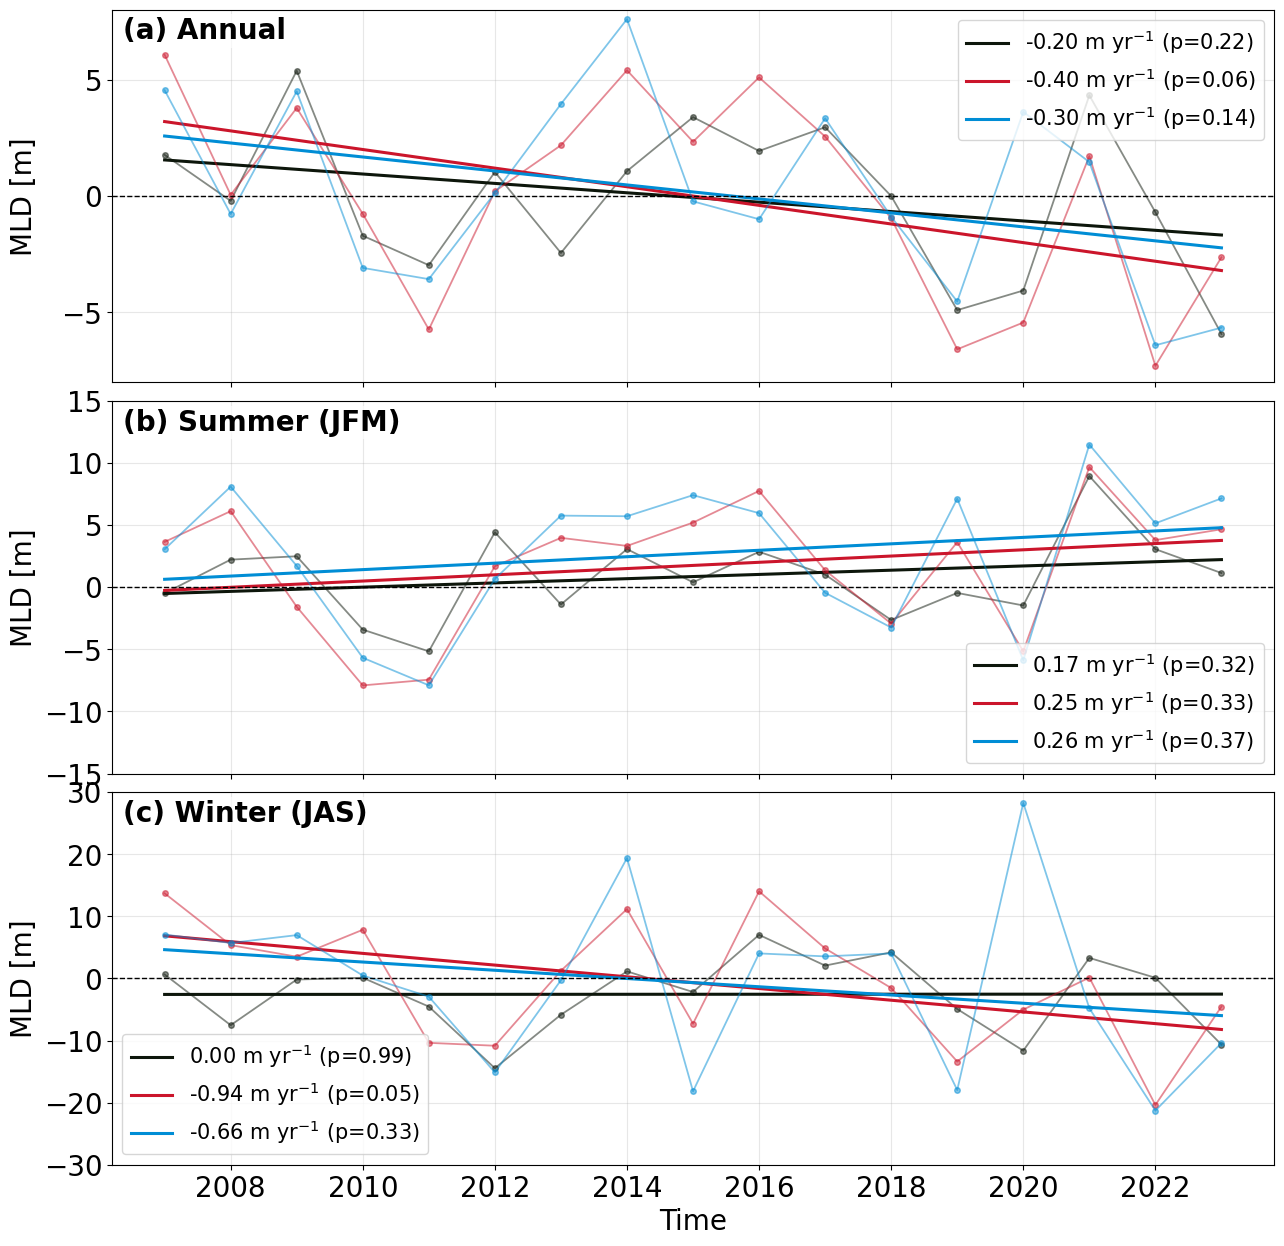

/tmp/ipykernel_2198499/4097771570.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig("/home/jupyter-vincent2/vincent/process_profiles/figures_2026/Figure_7_1D_trends.png", bbox_inches="tight", dpi=300)


In [5]:
# Seasonal trends over the full spatial domain (no xi1-based masking)

from turtle import pd


season_months = {
    "Annual": list(range(1, 13)),
    "Summer (JFM)": [1, 2, 3],
    "Winter (JAS)": [7, 8, 9],
}

ds_map = {
    "GLORYS": ds_G,
    "GLORYS_CL": ds_CL,
    "CMA": ds_CMA,
}

colors = {
    "GLORYS": G_color,
    "GLORYS_CL": CL_color,
    "CMA": CMA_color,
}

def seasonal_series_full_region(ds_in, months):
    ts = ds_in["mld"].mean(dim=("long", "lat"), skipna=True)
    sub = ts.where(ts["time"].dt.month.isin(months), drop=True)

    if set(months) == {12, 1, 2}:  # DJF
        season_year = xr.where(sub["time"].dt.month == 12, sub["time"].dt.year + 1, sub["time"].dt.year)
    else:
        season_year = sub["time"].dt.year

    season_year = season_year.rename("season_year")
    return sub.groupby(season_year).mean("time", skipna=True)

fig, axes = plt.subplots(3, 1, figsize=(15, 15), sharex=True, tight_layout=True, gridspec_kw={'hspace': 0.05})

for ax, (sname, months), letter in zip(axes, season_months.items(), ['a', 'b', 'c']):
    for name, ds_in in ds_map.items():
        ts_y = seasonal_series_full_region(ds_in, months)
        x = ts_y["season_year"].values.astype(float)
        y = ts_y.values
        m = np.isfinite(x) & np.isfinite(y)

        # Mean series (no legend entry)
        ax.plot(x[m], y[m], marker="o", ms=4, lw=1.3, color=colors[name], alpha=0.5, label="_nolegend_")

        # Trend line + legend entry
        if m.sum() >= 8:
            lr = linregress(x[m], y[m])
            yhat = lr.intercept + lr.slope * x[m]
            ax.plot(
                x[m], yhat, lw=2.2, color=colors[name],
                label=f"{lr.slope:.2f} m yr$^{{-1}}$ (p={lr.pvalue:.2f})"
            )

    ax.set_ylabel("MLD [m]")
    ax.axhline(0, color="k", linestyle="--", linewidth=1)
    ax.grid(alpha=0.3)
    ax.text(
        0.01, 0.98, f"({letter}) {sname}",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=20, fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2),
    )
    
axes[0].set_ylim(-8,8)
axes[0].legend(fontsize=legend_fs, loc="upper right",ncol=1)

axes[1].set_ylim(-15,15)
axes[1].legend(fontsize=legend_fs, loc="lower right",ncol=1)

axes[2].set_ylim(-30,30)
axes[2].legend(fontsize=legend_fs, loc="lower left",ncol=1)
    # ax.legend(fontsize=legend_fs, loc="upper right",ncol=1)

axes[-1].set_xlabel("Time")
fig.align_ylabels()
plt.show()
fig.savefig("/home/jupyter-vincent2/vincent/process_profiles/figures_2026/Figure_7_1D_trends.png", bbox_inches="tight", dpi=300)